# 02 — OGG Phase 1 Exploratory Data Analysis

This notebook characterizes the downloaded OGG flight, NOAA airport-weather, and Hawaii Storm Events datasets before we construct the time-aligned modeling table.


In [7]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
if (cwd / 'data').exists():
    ROOT = cwd
elif (cwd.parent / 'data').exists():
    ROOT = cwd.parent
else:
    raise FileNotFoundError(f'Cannot locate project root from {cwd}')

BTS_FILE = ROOT / 'data/raw/bts/ogg_flights_2020_2026.csv.gz'
WEATHER_FILE = ROOT / 'data/raw/weather/ogg_lcd_2020_2026.csv.gz'
STORM_FILE = ROOT / 'data/raw/incidents/hawaii_storm_events_2020_2026.csv.gz'

print('ROOT:', ROOT)
print('Flights exists:', BTS_FILE.exists())
print('Weather exists:', WEATHER_FILE.exists())
print('Storms exists:', STORM_FILE.exists())

for p in [BTS_FILE, WEATHER_FILE, STORM_FILE]:
    if not p.exists():
        raise FileNotFoundError(p)


ROOT: /workspaces/flight-disruption-ai
Flights exists: True
Weather exists: True
Storms exists: True


## 1. Flights: load, normalize, label, and inspect


In [8]:
flights = pd.read_csv(BTS_FILE, low_memory=False)
print('Raw flight columns:', list(flights.columns))

# The BTS downloader stores delay variables as *DelayMinutes.
# Create stable aliases used throughout the analysis.
if 'ArrDelay' not in flights.columns and 'ArrDelayMinutes' in flights.columns:
    flights['ArrDelay'] = pd.to_numeric(flights['ArrDelayMinutes'], errors='coerce')
if 'DepDelay' not in flights.columns and 'DepDelayMinutes' in flights.columns:
    flights['DepDelay'] = pd.to_numeric(flights['DepDelayMinutes'], errors='coerce')

for col in ['Cancelled', 'Diverted', 'ArrDelay', 'DepDelay']:
    if col in flights.columns:
        flights[col] = pd.to_numeric(flights[col], errors='coerce')

required = ['FlightDate', 'Origin', 'Dest', 'Cancelled']
missing_required = [c for c in required if c not in flights.columns]
if missing_required:
    raise KeyError(f'Missing required BTS columns: {missing_required}')

flights['FlightDate'] = pd.to_datetime(flights['FlightDate'], errors='coerce')
flights['year'] = flights['FlightDate'].dt.year
flights['month'] = flights['FlightDate'].dt.month
flights['year_month'] = flights['FlightDate'].dt.to_period('M').astype(str)
flights['direction'] = np.where(flights['Origin'].eq('OGG'), 'departure', 'arrival')
flights['covid_era'] = flights['FlightDate'].between('2020-03-01', '2021-05-31')

def disruption_class(r):
    if r.get('Cancelled', 0) == 1:
        return 'cancelled'
    d = r.get('ArrDelay', np.nan)
    if pd.isna(d):
        return 'unknown'
    if d < 15:
        return 'normal'
    if d < 180:
        return 'delay'
    return 'severe_delay'

flights['disruption_class'] = flights.apply(disruption_class, axis=1)

print('Flights:', flights.shape)
display(flights.head())
display(flights['disruption_class'].value_counts(dropna=False).to_frame('count'))
display((flights['disruption_class'].value_counts(normalize=True) * 100).round(2).to_frame('percent'))


Raw flight columns: ['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate', 'Reporting_Airline', 'DOT_ID_Reporting_Airline', 'Tail_Number', 'Flight_Number_Reporting_Airline', 'Origin', 'OriginCityName', 'Dest', 'DestCityName', 'CRSDepTime', 'DepTime', 'DepDelayMinutes', 'CRSArrTime', 'ArrTime', 'ArrDelayMinutes', 'Cancelled', 'CancellationCode', 'Diverted', 'CRSElapsedTime', 'ActualElapsedTime', 'AirTime', 'Distance', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']
Flights: (330615, 39)


,Year,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,Tail_Number,Flight_Number_Reporting_Airline,Origin,...,SecurityDelay,LateAircraftDelay,ArrDelay,DepDelay,year,month,year_month,direction,covid_era,disruption_class
0,2020,1,1,3,2020-01-01,HA,19690,N227HA,23.0,OAK,...,NaN,NaN,0.0,0.0,2020,1,2020-01,arrival,False,normal
1,2020,1,2,4,2020-01-02,HA,19690,N202HA,23.0,OAK,...,NaN,NaN,0.0,0.0,2020,1,2020-01,arrival,False,normal
2,2020,1,3,5,2020-01-03,HA,19690,N209HA,23.0,OAK,...,NaN,NaN,12.0,0.0,2020,1,2020-01,arrival,False,normal
3,2020,1,4,6,2020-01-04,HA,19690,N227HA,23.0,OAK,...,NaN,NaN,10.0,0.0,2020,1,2020-01,arrival,False,normal
4,2020,1,5,7,2020-01-05,HA,19690,N202HA,23.0,OAK,...,NaN,NaN,0.0,0.0,2020,1,2020-01,arrival,False,normal


,count
disruption_class,
normal,273287
delay,50528
cancelled,4417
severe_delay,1735
unknown,648


,percent
disruption_class,
normal,82.66
delay,15.28
cancelled,1.34
severe_delay,0.52
unknown,0.20


In [9]:
yearly_aggs = {
    'flights': ('FlightDate', 'size'),
    'cancelled': ('Cancelled', 'sum'),
}
if 'ArrDelay' in flights.columns:
    yearly_aggs['mean_arr_delay'] = ('ArrDelay', 'mean')
    yearly_aggs['median_arr_delay'] = ('ArrDelay', 'median')

yearly = flights.groupby('year').agg(**yearly_aggs)
yearly['cancel_rate_pct'] = 100 * yearly['cancelled'] / yearly['flights']
display(yearly.round(2))

carrier_col = 'Reporting_Airline' if 'Reporting_Airline' in flights.columns else None
if carrier_col:
    airline_aggs = {
        'flights': ('FlightDate', 'size'),
        'cancelled': ('Cancelled', 'sum'),
        'severe_delays': ('disruption_class', lambda s: (s == 'severe_delay').sum()),
    }
    if 'ArrDelay' in flights.columns:
        airline_aggs['mean_arr_delay'] = ('ArrDelay', 'mean')
    airlines = flights.groupby(carrier_col).agg(**airline_aggs)
    airlines['cancel_rate_pct'] = 100 * airlines['cancelled'] / airlines['flights']
    airlines['severe_delay_rate_pct'] = 100 * airlines['severe_delays'] / airlines['flights']
    display(airlines.sort_values('flights', ascending=False).round(2))
else:
    print('Reporting_Airline column not found; airline summary skipped.')

display(pd.crosstab(
    flights['direction'],
    flights['disruption_class'],
    normalize='index'
).mul(100).round(2))

covid_aggs = {
    'flights': ('FlightDate', 'size'),
    'cancelled': ('Cancelled', 'sum'),
}
if 'ArrDelay' in flights.columns:
    covid_aggs['mean_arr_delay'] = ('ArrDelay', 'mean')
display(flights.groupby('covid_era').agg(**covid_aggs).round(2))


,flights,cancelled,mean_arr_delay,median_arr_delay,cancel_rate_pct
year,,,,,
2020,26563,1600.0,5.27,0.0,6.02
2021,53849,408.0,9.00,0.0,0.76
2022,60111,601.0,12.52,0.0,1.00
2023,60077,662.0,11.38,0.0,1.10
2024,53085,510.0,7.44,0.0,0.96
2025,51011,386.0,8.54,0.0,0.76
2026,25919,250.0,11.00,0.0,0.96


,flights,cancelled,severe_delays,mean_arr_delay,cancel_rate_pct,severe_delay_rate_pct
Reporting_Airline,,,,,,
HA,148775,2130.0,572,9.16,1.43,0.38
WN,74396,865.0,189,6.83,1.16,0.25
AS,44540,624.0,286,11.65,1.40,0.64
UA,29357,400.0,260,10.20,1.36,0.89
AA,19418,222.0,245,15.43,1.14,1.26
DL,14129,176.0,183,13.82,1.25,1.30


disruption_class,cancelled,delay,normal,severe_delay,unknown
direction,,,,,
arrival,1.26,14.65,83.36,0.51,0.23
departure,1.41,15.92,81.96,0.54,0.16


,flights,cancelled,mean_arr_delay
covid_era,,,
False,296327,2756.0,10.02
True,34288,1661.0,6.10


,flights,cancelled,mean_arr_delay,cancel_rate_pct
year_month,,,,
2024-01,4524,181.0,11.81,4.00
2024-02,4142,29.0,9.88,0.70
2024-03,4598,23.0,6.87,0.50
2024-04,4308,35.0,7.51,0.81
2024-05,4338,64.0,8.86,1.48
2024-06,4550,29.0,6.45,0.64
2024-07,4845,57.0,8.28,1.18
2024-08,4539,17.0,6.15,0.37
2024-09,4163,13.0,5.23,0.31


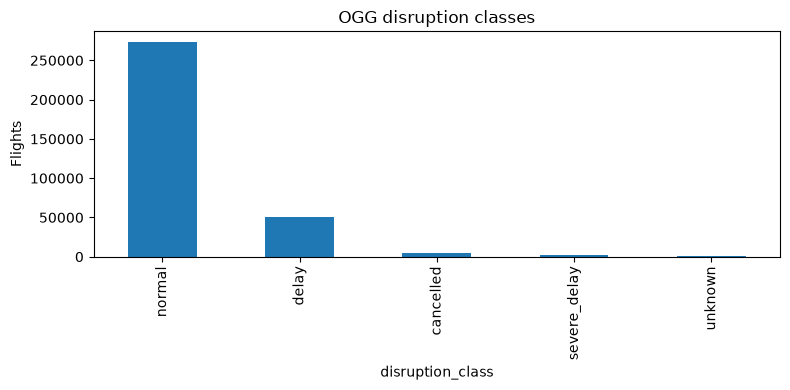

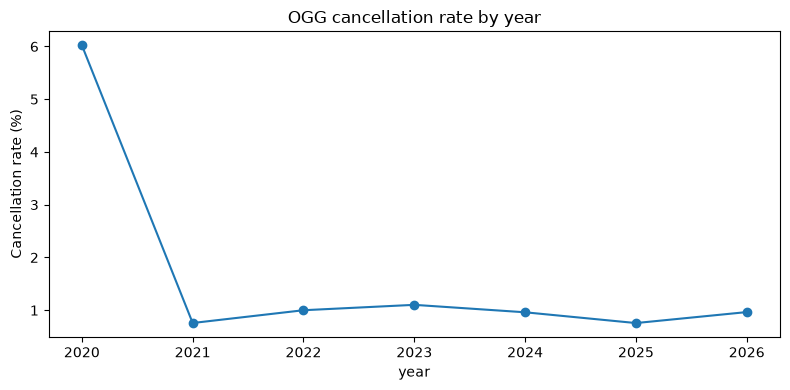

In [10]:
monthly_aggs = {
    'flights': ('FlightDate', 'size'),
    'cancelled': ('Cancelled', 'sum'),
}
if 'ArrDelay' in flights.columns:
    monthly_aggs['mean_arr_delay'] = ('ArrDelay', 'mean')

monthly = flights.groupby('year_month').agg(**monthly_aggs)
monthly['cancel_rate_pct'] = 100 * monthly['cancelled'] / monthly['flights']
display(monthly.tail(30).round(2))

flights['disruption_class'].value_counts().plot(
    kind='bar', figsize=(8, 4), title='OGG disruption classes'
)
plt.ylabel('Flights')
plt.tight_layout()
plt.show()

yearly['cancel_rate_pct'].plot(
    marker='o', figsize=(8, 4), title='OGG cancellation rate by year'
)
plt.ylabel('Cancellation rate (%)')
plt.tight_layout()
plt.show()


## 2. NOAA airport weather: schema and missingness


In [11]:
weather = pd.read_csv(WEATHER_FILE, low_memory=False)
print('Weather:', weather.shape)
display(weather.head())
display(pd.DataFrame({'column': weather.columns}))

missing = (
    weather.isna().mean().mul(100)
    .sort_values(ascending=False)
    .rename('missing_pct')
    .to_frame()
)
display(missing.head(30).round(2))

keywords = [
    'date', 'hourly', 'wind', 'gust', 'visibility', 'precip',
    'pressure', 'temperature', 'dew', 'sky', 'weather'
]
candidate_cols = [
    c for c in weather.columns
    if any(k in c.lower() for k in keywords)
]
display(pd.DataFrame({'candidate_weather_feature': candidate_cols}))


Weather: (66074, 125)


,STATION,DATE,LATITUDE,LONGITUDE,ELEVATION,NAME,REPORT_TYPE,SOURCE,HourlyAltimeterSetting,HourlyDewPointTemperature,...,BackupDirection,BackupDistance,BackupDistanceUnit,BackupElements,BackupElevation,BackupEquipment,BackupLatitude,BackupLongitude,BackupName,WindEquipmentChangeDate
0,91190022516,2020-01-01T00:13:00,20.88871,-156.43453,14.0,"KAHULUI AIRPORT, HI US",FM-15,4,30.06,61,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,91190022516,2020-01-01T00:13:00,20.88871,-156.43453,14.0,"KAHULUI AIRPORT, HI US",FM-16,4,30.06,61,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,91190022516,2020-01-01T00:24:00,20.88871,-156.43453,14.0,"KAHULUI AIRPORT, HI US",FM-15,4,30.07,59,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,91190022516,2020-01-01T00:24:00,20.88871,-156.43453,14.0,"KAHULUI AIRPORT, HI US",FM-16,7,30.07,59,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,91190022516,2020-01-01T00:54:00,20.88871,-156.43453,14.0,"KAHULUI AIRPORT, HI US",FM-15,7,30.06,59,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,column
0,STATION
1,DATE
2,LATITUDE
3,LONGITUDE
4,ELEVATION
...,...
120,BackupEquipment
121,BackupLatitude
122,BackupLongitude
123,BackupName


,missing_pct
DailySnowDepth,100.00
MonthlyAverageRH,100.00
MonthlyDewpointTemperature,100.00
DailySnowfall,100.00
BackupName,100.00
MonthlyTotalSnowfall,100.00
MonthlyWetBulb,100.00
DSNW,100.00
DYHF,100.00
MonthlyGreatestSnowfallDate,100.00


,candidate_weather_feature
0,DATE
1,HourlyAltimeterSetting
2,HourlyDewPointTemperature
3,HourlyDryBulbTemperature
4,HourlyPrecipitation
...,...
75,ShortDurationPrecipitationValue100
76,ShortDurationPrecipitationValue120
77,ShortDurationPrecipitationValue150
78,ShortDurationPrecipitationValue180


## 3. NOAA Hawaii Storm Events: event types and timing


In [12]:
storms = pd.read_csv(STORM_FILE, low_memory=False)
print('Storm events:', storms.shape)
display(storms.head())

if 'EVENT_TYPE' in storms.columns:
    display(storms['EVENT_TYPE'].value_counts().head(30).to_frame('count'))
else:
    print('EVENT_TYPE not found.')

if {'YEAR', 'EVENT_TYPE'}.issubset(storms.columns):
    display(pd.crosstab(storms['YEAR'], storms['EVENT_TYPE']))

useful = [
    c for c in [
        'EVENT_ID', 'EVENT_TYPE', 'BEGIN_DATE_TIME', 'END_DATE_TIME',
        'CZ_NAME', 'SOURCE', 'MAGNITUDE', 'DEATHS_DIRECT',
        'INJURIES_DIRECT', 'DAMAGE_PROPERTY', 'DAMAGE_CROPS',
        'BEGIN_LAT', 'BEGIN_LON', 'END_LAT', 'END_LON',
        'EVENT_NARRATIVE'
    ]
    if c in storms.columns
]
display(storms[useful].head(20))


Storm events: (2613, 51)


,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,...,END_RANGE,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE
0,202003,20,1900,202003,22,1400,145695,875114,HAWAII,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A rather modest northwest swell produced surf ...,NaN,CSV
1,202003,20,1900,202003,22,1400,145695,875115,HAWAII,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A rather modest northwest swell produced surf ...,NaN,CSV
2,202003,24,400,202003,25,1900,145698,875119,HAWAII,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,The combination of a swell from the southern h...,NaN,CSV
3,202003,24,400,202003,28,1900,145698,875120,HAWAII,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,The combination of a swell from the southern h...,NaN,CSV
4,202003,16,2330,202003,17,1539,145684,875053,HAWAII,15,...,0.83,S,PRINCEVILLE,22.2095,-159.4815,22.2102,-159.4797,"An upper low, known as a kona low in Hawaii, a...",Kuhio Highway near the Hanalei Bridge became i...,CSV


,count
EVENT_TYPE,
High Surf,1240
Drought,710
Heavy Rain,346
Flash Flood,108
High Wind,46
Strong Wind,44
Flood,37
Wildfire,28
Debris Flow,11


EVENT_TYPE,Blizzard,Debris Flow,Drought,Dust Devil,Flash Flood,Flood,Funnel Cloud,Hail,Heavy Rain,Heavy Snow,...,Lightning,Storm Surge/Tide,Strong Wind,Thunderstorm Wind,Tropical Storm,Tsunami,Volcanic Ashfall,Wildfire,Winter Storm,Winter Weather
YEAR,,,,,,,,,,,,,,,,,,,,,
2020,0,1,86,0,12,0,1,0,124,0,...,0,0,8,0,0,0,0,5,0,0
2021,0,6,180,0,24,0,1,1,159,0,...,1,0,2,0,0,0,0,3,2,0
2022,1,0,240,0,13,0,0,0,59,0,...,0,0,14,4,0,0,1,2,0,2
2023,0,3,70,0,12,17,0,1,1,1,...,2,0,20,0,1,0,5,11,1,4
2024,0,1,54,0,19,13,1,0,1,0,...,0,0,0,1,3,0,0,4,0,0
2025,0,0,77,1,2,5,0,0,0,0,...,0,1,0,4,0,1,0,3,0,0
2026,0,0,3,0,26,2,0,0,2,0,...,1,0,0,0,0,0,1,0,0,0


,EVENT_ID,EVENT_TYPE,BEGIN_DATE_TIME,END_DATE_TIME,CZ_NAME,SOURCE,MAGNITUDE,DEATHS_DIRECT,INJURIES_DIRECT,DAMAGE_PROPERTY,DAMAGE_CROPS,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EVENT_NARRATIVE
0,875114,High Surf,20-MAR-20 19:00:00,22-MAR-20 14:00:00,OAHU NORTH SHORE,Trained Spotter,NaN,0,0,0.00K,0.00K,NaN,NaN,NaN,NaN,NaN
1,875115,High Surf,20-MAR-20 19:00:00,22-MAR-20 14:00:00,OAHU KOOLAU,Trained Spotter,NaN,0,0,0.00K,0.00K,NaN,NaN,NaN,NaN,NaN
2,875119,High Surf,24-MAR-20 04:00:00,25-MAR-20 19:00:00,NIIHAU,Trained Spotter,NaN,0,0,0.00K,0.00K,NaN,NaN,NaN,NaN,NaN
3,875120,High Surf,24-MAR-20 04:00:00,28-MAR-20 19:00:00,KAUAI WINDWARD,Trained Spotter,NaN,0,0,0.00K,0.00K,NaN,NaN,NaN,NaN,NaN
4,875053,Flash Flood,16-MAR-20 23:30:00,17-MAR-20 15:39:00,KAUAI,Emergency Manager,NaN,0,0,0.00K,0.00K,22.2095,-159.4815,22.2102,-159.4797,Kuhio Highway near the Hanalei Bridge became i...
5,875045,Flash Flood,15-MAR-20 14:02:00,15-MAR-20 15:52:00,HONOLULU,Department of Highways,NaN,0,0,0.00K,0.00K,21.4892,-157.8511,21.4891,-157.8494,Kamehameha Highway was closed in Waikane on Oa...
6,875046,Heavy Rain,15-MAR-20 16:06:00,15-MAR-20 18:52:00,HAWAII,Official NWS Observations,NaN,0,0,0.00K,0.00K,20.0463,-155.6818,19.3806,-155.8163,NaN
7,875047,Heavy Rain,15-MAR-20 16:34:00,15-MAR-20 21:39:00,MAUI,Official NWS Observations,NaN,0,0,0.00K,0.00K,21.0069,-156.6369,20.6933,-156.3142,NaN
8,874989,High Surf,01-MAR-20 00:00:00,04-MAR-20 13:00:00,KAUAI WINDWARD,Trained Spotter,NaN,0,0,0.00K,0.00K,NaN,NaN,NaN,NaN,NaN
9,875049,Flash Flood,16-MAR-20 12:05:00,16-MAR-20 17:36:00,KAUAI,Emergency Manager,NaN,0,0,0.00K,0.00K,22.2088,-159.4826,22.2095,-159.4800,Kuhio Highway was closed near the Hanalei Brid...


## 4. Broad storm-day overlap check

This is intentionally broad: **any Hawaii Storm Event active on the same calendar day**. Notebook 03 will refine this to Maui/OGG-specific spatial and hourly matching.


In [13]:
if {'BEGIN_DATE_TIME', 'END_DATE_TIME'}.issubset(storms.columns):
    storms['begin_dt'] = pd.to_datetime(
        storms['BEGIN_DATE_TIME'], errors='coerce'
    )
    storms['end_dt'] = pd.to_datetime(
        storms['END_DATE_TIME'], errors='coerce'
    )

    valid = storms[['begin_dt', 'end_dt']].dropna()
    valid = valid[valid['end_dt'] >= valid['begin_dt']]

    ranges = []
    for r in valid.itertuples(index=False):
        ranges.extend(
            pd.date_range(
                r.begin_dt.normalize(),
                r.end_dt.normalize(),
                freq='D'
            )
        )

    if ranges:
        storm_dates = pd.DatetimeIndex(pd.Series(ranges).drop_duplicates())
        flights['storm_day_any_hawaii'] = (
            flights['FlightDate'].dt.normalize().isin(storm_dates)
        )

        overlap_aggs = {
            'flights': ('FlightDate', 'size'),
            'cancelled': ('Cancelled', 'sum'),
        }
        if 'ArrDelay' in flights.columns:
            overlap_aggs['mean_arr_delay'] = ('ArrDelay', 'mean')

        overlap = flights.groupby('storm_day_any_hawaii').agg(**overlap_aggs)
        overlap['cancel_rate_pct'] = (
            100 * overlap['cancelled'] / overlap['flights']
        )
        display(overlap.round(2))
    else:
        print('No valid storm date ranges were parsed.')
else:
    print('Storm datetime fields are missing; overlap deferred.')


/tmp/ipykernel_46002/760826130.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  storms['begin_dt'] = pd.to_datetime(
/tmp/ipykernel_46002/760826130.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  storms['end_dt'] = pd.to_datetime(


,flights,cancelled,mean_arr_delay,cancel_rate_pct
storm_day_any_hawaii,,,,
False,54349,521.0,10.69,0.96
True,276266,3896.0,9.42,1.41


## What to record after running

Keep the outputs for:

- class balance;
- yearly cancellation rates;
- airline summary;
- arrivals vs departures;
- weather shape, missingness, and candidate columns;
- storm-event type counts;
- broad storm-day overlap.

These results determine the exact merge strategy and baseline model design.
